# Melanoma Detection — ISIC Challenge Dataset 2020
### MobileNetV2 vs ResNet50 — Feature-Space SMOTE | 3-Run Experiment
**Dataset:** ISIC Challenge Dataset-2020 — Sumaiya Binte Shahid  
**Kaggle:** `sumaiyabinteshahid/isic-challenge-dataset-2020`

**Note:** The test folder labels are not publicly released (competition format).  
We perform an **80/20 stratified split** from the labelled train set instead.

**Sampling strategy (consistent with HAM10000 experiment):**
- All real malignant (80% of 584) + SMOTE synthetic → **5,000 malignant**
- Random sample of 5,000 from benign pool → **5,000 benign**
- Total training: **10,000 images (balanced 50/50)**
- Test set: 20% of real images per class (real only, no synthetic)

**Metrics:** Accuracy · Sensitivity · PPV · NPV · AUC · F1 · Inference Time · Model Size

## 1. Imports

In [1]:
import os
import itertools
import time
import gc

import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style('whitegrid')

from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                             recall_score, roc_curve, auc)
from sklearn.neighbors import NearestNeighbors
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.applications import MobileNetV2, ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

print("TF version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

2026-03-13 11:04:19.062663: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773399859.326271      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773399859.416630      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773399859.999006      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773399859.999105      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773399859.999108      17 computation_placer.cc:177] computation placer alr

TF version: 2.19.0
GPU available: []


2026-03-13 11:04:49.514429: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [2]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        if file == "ISIC_2020_Train_Metadata.csv":
            print(os.path.join(root, file))

/kaggle/input/datasets/sumaiyabinteshahid/isic-challenge-dataset-2020/ISIC_2020_Dataset/ISIC_2020_Train_Metadata.csv


## 2. Discover Dataset Structure

In [3]:
base = '/kaggle/input/isic-challenge-dataset-2020'
for root, dirs, files in os.walk(base):
    level = root.replace(base, '').count(os.sep)
    if level <= 3:
        indent = '  ' * level
        print(f"{indent}{os.path.basename(root)}/  ({len(files)} files)")

## 3. Configuration

In [4]:
import os

# ── Paths ─────────────────────────────────────────────────────────
import os

# ── Paths ─────────────────────────────────────────────
BASE_DIR = "/kaggle/input/datasets/sumaiyabinteshahid/isic-challenge-dataset-2020/ISIC_2020_Dataset"

IMAGE_DIR = os.path.join(BASE_DIR, "train")

CSV_PATH = os.path.join(BASE_DIR, "ISIC_2020_Train_Metadata.csv")

print("Image dir :", IMAGE_DIR)
print("CSV path  :", CSV_PATH)
# ── Experiment config ──────────────────────────────────────────────
TARGET_PER_CLASS = 5000
RANDOM_STATE     = 42
IMG_SIZE         = (224, 224)
CHANNELS         = 3
IMG_SHAPE        = (IMG_SIZE[0], IMG_SIZE[1], CHANNELS)

BATCH_SIZE = 16
EPOCHS     = 20
N_RUNS     = 3
SMOTE_BATCH = 500

print(f"Image dir    : {IMAGE_DIR}")
print(f"CSV path     : {CSV_PATH}")
print(f"Target/class : {TARGET_PER_CLASS}")
print(f"Image shape  : {IMG_SHAPE}")
print(f"Batch size   : {BATCH_SIZE}")
print(f"Max epochs   : {EPOCHS}")
print(f"Runs         : {N_RUNS}")

Image dir : /kaggle/input/datasets/sumaiyabinteshahid/isic-challenge-dataset-2020/ISIC_2020_Dataset/train
CSV path  : /kaggle/input/datasets/sumaiyabinteshahid/isic-challenge-dataset-2020/ISIC_2020_Dataset/ISIC_2020_Train_Metadata.csv
Image dir    : /kaggle/input/datasets/sumaiyabinteshahid/isic-challenge-dataset-2020/ISIC_2020_Dataset/train
CSV path     : /kaggle/input/datasets/sumaiyabinteshahid/isic-challenge-dataset-2020/ISIC_2020_Dataset/ISIC_2020_Train_Metadata.csv
Target/class : 5000
Image shape  : (224, 224, 3)
Batch size   : 16
Max epochs   : 20
Runs         : 3


## 4. Load Metadata CSV

In [5]:
meta = pd.read_csv(CSV_PATH)
print("CSV shape   :", meta.shape)
print("CSV columns :", meta.columns.tolist())
print("\nTarget distribution:")
print(meta['target'].value_counts())
print(f"\nMalignant : {(meta['target']==1).sum()}")
print(f"Benign    : {(meta['target']==0).sum()}")
meta.head()

CSV shape   : (33126, 9)
CSV columns : ['image_name', 'patient_id', 'lesion_id', 'sex', 'age_approx', 'anatom_site_general_challenge', 'diagnosis', 'benign_malignant', 'target']

Target distribution:
target
0    32542
1      584
Name: count, dtype: int64

Malignant : 584
Benign    : 32542


,image_name,patient_id,lesion_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target
0,ISIC_2637011,IP_7279968,IL_7972535,male,45.0,head/neck,unknown,benign,0
1,ISIC_0015719,IP_3075186,IL_4649854,female,45.0,upper extremity,unknown,benign,0
2,ISIC_0052212,IP_2842074,IL_9087444,female,50.0,lower extremity,nevus,benign,0
3,ISIC_0068279,IP_6890425,IL_4255399,female,45.0,head/neck,unknown,benign,0
4,ISIC_0074268,IP_8723313,IL_6898037,female,55.0,upper extremity,unknown,benign,0


## 5. Build Train / Test Split

In [6]:
# Build filepaths — images are named by image_name column
# Try both with and without extension
def build_filepath(image_name, image_dir):
    name = str(image_name)
    for ext in ['.jpg', '.jpeg', '.png', '']:
        fp = os.path.join(image_dir, name + ext if not name.endswith(ext) else name)
        if os.path.exists(fp):
            return fp
    # fallback — assume .jpg
    return os.path.join(image_dir, name + '.jpg')

# Detect the correct image ID column
id_col = None
for col in ['image_name', 'isic_id', 'image_id', 'ISIC_id']:
    if col in meta.columns:
        id_col = col
        break
if id_col is None:
    id_col = meta.columns[0]   # fallback to first column
print(f"Using image ID column: '{id_col}'")

meta['filepaths'] = meta[id_col].apply(lambda x: build_filepath(x, IMAGE_DIR))
meta['labels']    = meta['target'].map({0: 'benign', 1: 'malignant'})

# Verify files exist
exist_check = meta['filepaths'].head(10).apply(os.path.exists)
print(f"\nFile existence check (first 10): {exist_check.tolist()}")
print(f"Files found: {exist_check.sum()}/10")

# ── Separate classes ───────────────────────────────────────────────────────
df_malignant = meta[meta['labels'] == 'malignant'].reset_index(drop=True)
df_benign    = meta[meta['labels'] == 'benign'].reset_index(drop=True)
print(f"\nTotal malignant : {len(df_malignant)}")
print(f"Total benign    : {len(df_benign)}")

# ── 80/20 stratified split ────────────────────────────────────────────────
train_mal, test_mal = train_test_split(df_malignant, test_size=0.2,
                                       random_state=RANDOM_STATE)
n_benign_test  = len(test_mal)
n_benign_train = TARGET_PER_CLASS

df_benign_sampled = df_benign.sample(n=n_benign_train + n_benign_test,
                                      random_state=RANDOM_STATE)
train_ben = df_benign_sampled.iloc[:n_benign_train]
test_ben  = df_benign_sampled.iloc[n_benign_train:]

# ── Combine ────────────────────────────────────────────────────────────────
train_df = pd.concat([train_mal[['filepaths','labels']],
                      train_ben[['filepaths','labels']]]).reset_index(drop=True)
test_df  = pd.concat([test_mal[['filepaths','labels']],
                      test_ben[['filepaths','labels']]]).reset_index(drop=True)

train_df = train_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
test_df  = test_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"\nTrain set (before SMOTE):")
print(train_df['labels'].value_counts())
print(f"\nTest set (real images only):")
print(test_df['labels'].value_counts())
print(f"\nSMOTE will generate {TARGET_PER_CLASS - len(train_mal)} synthetic malignant images")
train_df.head()

Using image ID column: 'image_name'

File existence check (first 10): [True, True, True, True, True, True, True, True, True, True]
Files found: 10/10

Total malignant : 584
Total benign    : 32542

Train set (before SMOTE):
labels
benign       5000
malignant     467
Name: count, dtype: int64

Test set (real images only):
labels
malignant    117
benign       117
Name: count, dtype: int64

SMOTE will generate 4533 synthetic malignant images


,filepaths,labels
0,/kaggle/input/datasets/sumaiyabinteshahid/isic...,benign
1,/kaggle/input/datasets/sumaiyabinteshahid/isic...,benign
2,/kaggle/input/datasets/sumaiyabinteshahid/isic...,benign
3,/kaggle/input/datasets/sumaiyabinteshahid/isic...,benign
4,/kaggle/input/datasets/sumaiyabinteshahid/isic...,benign


## 6. Class Distribution

/tmp/ipykernel_17/2790730677.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette=colors, ax=ax)
/tmp/ipykernel_17/2790730677.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette=colors, ax=ax)


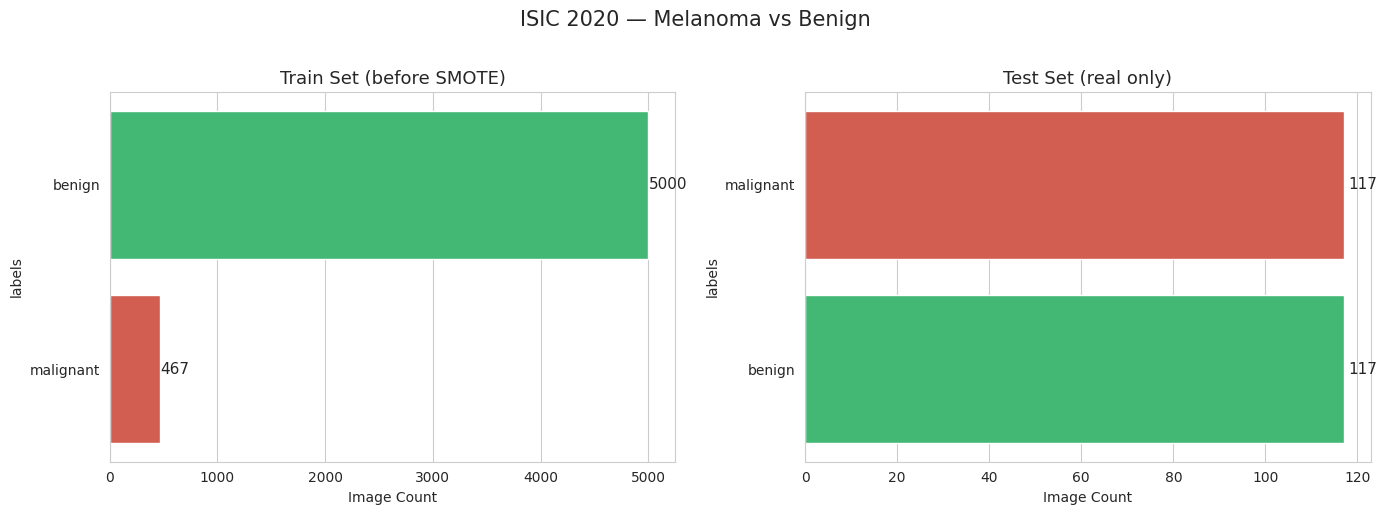

Train imbalance ratio: 5000 / 467 = 10.71x


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, df, title in zip(axes, [train_df, test_df],
                         ['Train Set (before SMOTE)', 'Test Set (real only)']):
    counts = df['labels'].value_counts()
    colors = ['#e74c3c' if l == 'malignant' else '#2ecc71' for l in counts.index]
    sns.barplot(x=counts.values, y=counts.index, palette=colors, ax=ax)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Image Count')
    for i, v in enumerate(counts.values):
        ax.text(v + 1, i, str(v), va='center', fontsize=11)
plt.suptitle('ISIC 2020 — Melanoma vs Benign', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

ratio = train_df['labels'].value_counts()
print(f"Train imbalance ratio: {ratio.max()} / {ratio.min()} = {ratio.max()/ratio.min():.2f}x")

## 7. Feature-Space SMOTE

In [8]:
def extract_embeddings(df, img_size=IMG_SIZE, batch_size=SMOTE_BATCH):
    extractor = MobileNetV2(include_top=False, weights='imagenet',
                            input_shape=(img_size[0], img_size[1], 3),
                            pooling='avg')
    extractor.trainable = False

    all_embeddings, valid_indices = [], []
    filepaths = df['filepaths'].values

    for start in range(0, len(filepaths), batch_size):
        batch_paths = filepaths[start:start + batch_size]
        batch_imgs, batch_idxs = [], []
        for i, fp in enumerate(batch_paths):
            img = cv2.imread(fp)
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, img_size).astype(np.float32) / 255.0
            batch_imgs.append(img)
            batch_idxs.append(start + i)
        if not batch_imgs:
            continue
        embeddings = extractor.predict(np.array(batch_imgs), verbose=0)
        all_embeddings.append(embeddings)
        valid_indices.extend(batch_idxs)
        if (start // batch_size) % 5 == 0:
            print(f"  Extracted {min(start+batch_size, len(filepaths))}/{len(filepaths)} images...")

    del extractor
    gc.collect()
    return np.vstack(all_embeddings), df.iloc[valid_indices].reset_index(drop=True)


def apply_feature_smote(train_df, target_per_class=TARGET_PER_CLASS, img_size=IMG_SIZE):
    class_counts   = train_df['labels'].value_counts()
    majority_class = class_counts.idxmax()
    minority_class = class_counts.idxmin()

    print(f"Before SMOTE:")
    print(f"  {majority_class}: {class_counts[majority_class]}")
    print(f"  {minority_class}: {class_counts[minority_class]}")
    print(f"  Synthetic to generate: {target_per_class - class_counts[minority_class]}")

    print("\nExtracting embeddings from all training images...")
    X_emb, df_valid = extract_embeddings(train_df, img_size=img_size)

    unique_labels = sorted(df_valid['labels'].unique())
    y_encoded     = np.array([unique_labels.index(l) for l in df_valid['labels']])

    print(f"\nEmbedding matrix: {X_emb.shape}  ({X_emb.nbytes/1e6:.1f} MB)")
    print("Running SMOTE in embedding space...")

    sm = SMOTE(random_state=RANDOM_STATE, k_neighbors=5,
               sampling_strategy={unique_labels.index(minority_class): target_per_class})
    X_res, y_res = sm.fit_resample(X_emb, y_encoded)
    n_original  = len(df_valid)
    n_synthetic = len(X_res) - n_original
    print(f"After SMOTE: {len(X_res)} total  ({n_synthetic} synthetic malignant samples)")

    minority_mask = y_encoded == unique_labels.index(minority_class)
    X_minority    = X_emb[minority_mask]
    df_minority   = df_valid[minority_mask].reset_index(drop=True)

    knn = NearestNeighbors(n_neighbors=2, metric='euclidean')
    knn.fit(X_minority)

    smote_dir = '/kaggle/working/smote_synthetic'
    os.makedirs(smote_dir, exist_ok=True)

    new_filepaths = list(df_valid['filepaths'])
    new_labels    = list(df_valid['labels'])

    print("Generating synthetic images via pixel blending...")
    synthetic_embeddings = X_res[n_original:]
    dists_all, idxs_all  = knn.kneighbors(synthetic_embeddings)

    for k in range(n_synthetic):
        fp1  = df_minority.iloc[idxs_all[k][0]]['filepaths']
        fp2  = df_minority.iloc[idxs_all[k][1]]['filepaths']
        img1 = cv2.imread(fp1)
        img2 = cv2.imread(fp2)
        if img1 is None or img2 is None:
            continue
        img1    = cv2.resize(img1, img_size).astype(np.float32)
        img2    = cv2.resize(img2, img_size).astype(np.float32)
        d1, d2  = dists_all[k][0] + 1e-8, dists_all[k][1] + 1e-8
        w1      = d2 / (d1 + d2)
        blended = (w1 * img1 + (1 - w1) * img2).astype(np.uint8)
        fname   = os.path.join(smote_dir, f'synthetic_{k}.png')
        cv2.imwrite(fname, blended)
        new_filepaths.append(fname)
        new_labels.append(minority_class)
        if k % 500 == 0:
            print(f"  Saved {k}/{n_synthetic} synthetic images...")

    del X_emb, X_res
    gc.collect()

    balanced_df = pd.DataFrame({'filepaths': new_filepaths, 'labels': new_labels})
    balanced_df = balanced_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
    print("\nFinal class distribution:")
    print(balanced_df['labels'].value_counts())
    return balanced_df

train_df_balanced = apply_feature_smote(train_df)

Before SMOTE:
  benign: 5000
  malignant: 467
  Synthetic to generate: 4533

Extracting embeddings from all training images...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
  Extracted 500/5467 images...
  Extracted 3000/5467 images...
  Extracted 5467/5467 images...

Embedding matrix: (5467, 1280)  (28.0 MB)
Running SMOTE in embedding space...
After SMOTE: 10000 total  (4533 synthetic malignant samples)
Generating synthetic images via pixel blending...
  Saved 0/4533 synthetic images...
  Saved 500/4533 synthetic images...
  Saved 1000/4533 synthetic images...
  Saved 1500/4533 synthetic images...
  Saved 2000/4533 synthetic images...
  Saved 2500/4533 synthetic images...
  Saved 3000/4533 synthetic images...
  Saved 3500/4533 synthetic images...
  Saved 4000/4533 synthetic images...
  Saved 4500/4533 synthetic images...

Final class distribution:
labels
malignant    5000
benign       5000
Name: count, dtype: int64


## 8. Preview Balanced Dataset

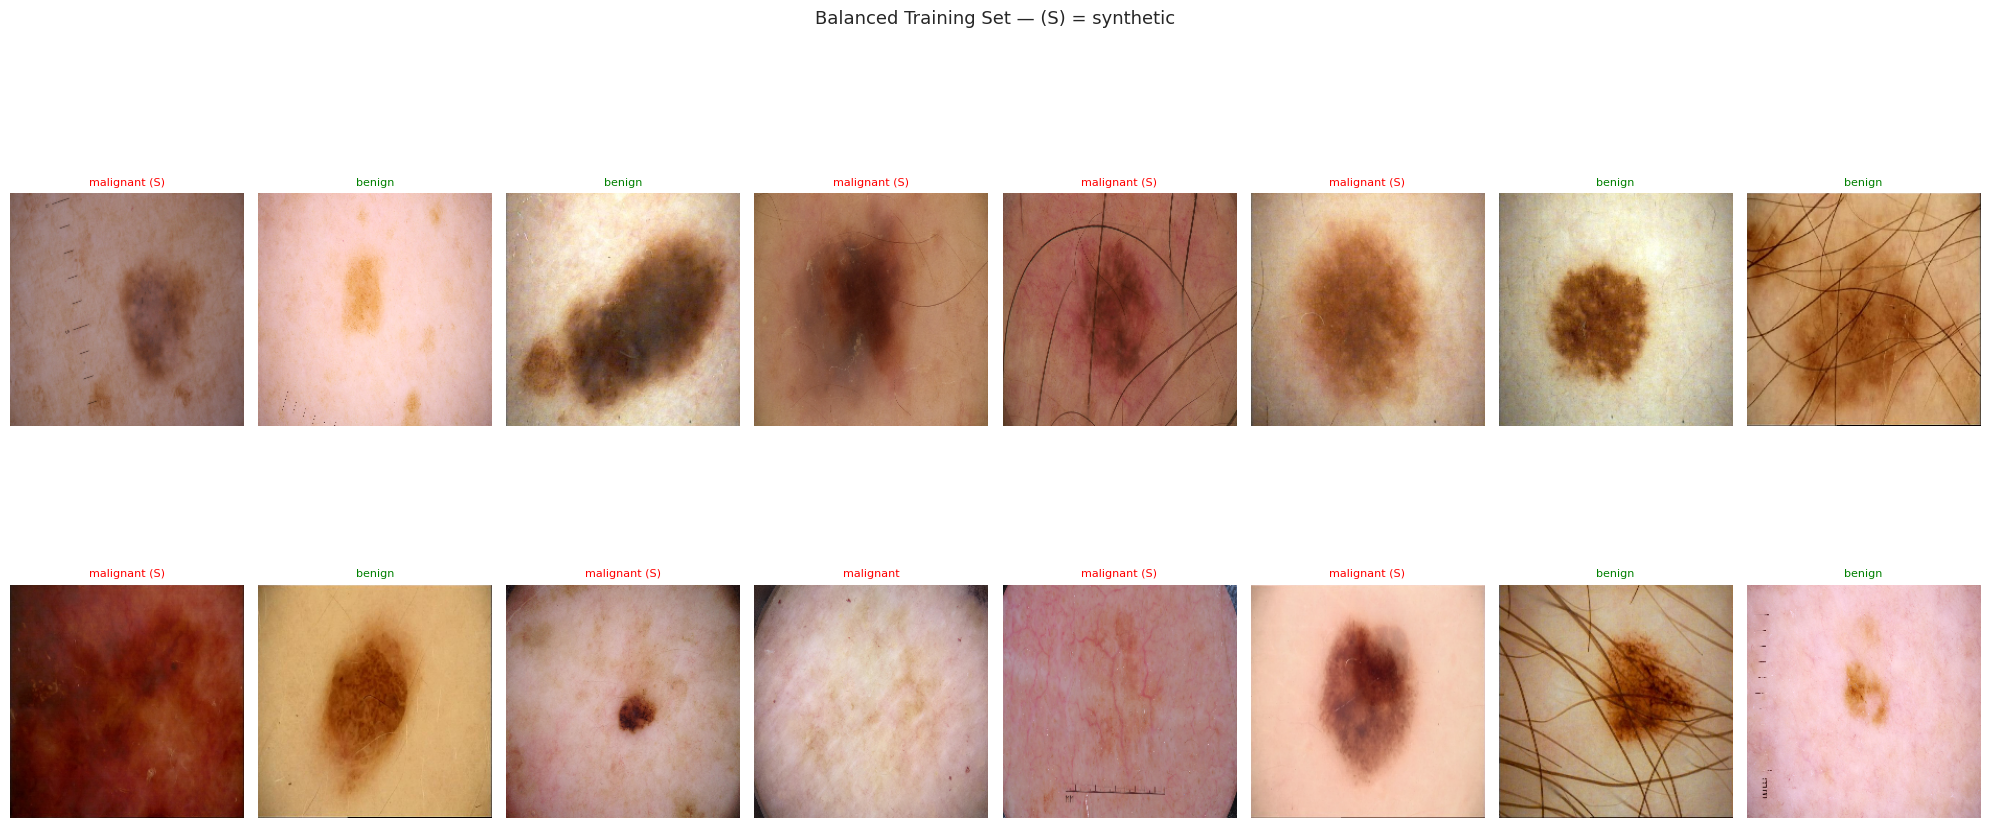

In [9]:
sample = train_df_balanced.sample(16, random_state=1).reset_index(drop=True)
plt.figure(figsize=(20, 10))
for i, row in sample.iterrows():
    img = cv2.imread(row['filepaths'])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    plt.subplot(2, 8, i + 1)
    plt.imshow(img / 255.)
    synth = ' (S)' if 'synthetic' in row['filepaths'] else ''
    plt.title(row['labels'] + synth, fontsize=8,
              color='red' if row['labels'] == 'malignant' else 'green')
    plt.axis('off')
plt.suptitle('Balanced Training Set — (S) = synthetic', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Helper Functions

In [10]:
def build_generators(train_df_b, test_df, img_size=IMG_SIZE, batch_size=BATCH_SIZE):
    tr_gen = ImageDataGenerator()
    ts_gen = ImageDataGenerator()
    train_gen = tr_gen.flow_from_dataframe(
        dataframe=train_df_b, x_col='filepaths', y_col='labels',
        target_size=img_size, class_mode='categorical',
        color_mode='rgb', shuffle=True, batch_size=batch_size)
    test_gen = ts_gen.flow_from_dataframe(
        dataframe=test_df, x_col='filepaths', y_col='labels',
        target_size=img_size, class_mode='categorical',
        color_mode='rgb', shuffle=False, batch_size=batch_size)
    return train_gen, test_gen


def compute_npv_ppv(cm):
    TN, FP, FN, TP = cm.ravel()
    PPV = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    NPV = TN / (TN + FN) if (TN + FN) > 0 else 0.0
    return PPV, NPV


def build_mobilenetv2(img_shape, class_count):
    base = MobileNetV2(include_top=False, weights='imagenet',
                       input_shape=img_shape, pooling='max')
    base.trainable = False
    m = Sequential([base,
                    BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001),
                    Dense(512, activation='relu'),
                    Dropout(0.5),
                    Dense(class_count, activation='softmax')])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m


def build_resnet50(img_shape, class_count):
    base = ResNet50(include_top=False, weights='imagenet',
                    input_shape=img_shape, pooling='max')
    base.trainable = False
    m = Sequential([base,
                    BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001),
                    Dense(512, activation='relu'),
                    Dropout(0.5),
                    Dense(class_count, activation='softmax')])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m


def plot_history(history, model_name, run):
    train_acc  = history.history['accuracy']
    train_loss = history.history['loss']
    val_acc    = history.history['val_accuracy']
    val_loss   = history.history['val_loss']
    Epochs     = list(range(1, len(train_acc) + 1))
    i_loss, i_acc = np.argmin(val_loss), np.argmax(val_acc)

    plt.figure(figsize=(20, 8))
    plt.style.use('fivethirtyeight')
    plt.subplot(1, 2, 1)
    plt.plot(Epochs, train_loss, 'r', label='Train Loss')
    plt.plot(Epochs, val_loss,   'g', label='Val Loss')
    plt.scatter(i_loss+1, val_loss[i_loss], s=150, c='blue', label=f'Best epoch={i_loss+1}')
    plt.title(f'{model_name} — Loss (Run {run})')
    plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(Epochs, train_acc, 'r', label='Train Accuracy')
    plt.plot(Epochs, val_acc,   'g', label='Val Accuracy')
    plt.scatter(i_acc+1, val_acc[i_acc], s=150, c='blue', label=f'Best epoch={i_acc+1}')
    plt.title(f'{model_name} — Accuracy (Run {run})')
    plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend()
    plt.tight_layout()
    plt.show()


def evaluate_model(model, test_gen, classes, model_name, run):
    preds  = model.predict(test_gen)
    y_pred = np.argmax(preds, axis=1)
    y_true = test_gen.classes

    report      = classification_report(y_true, y_pred, target_names=classes, output_dict=True)
    print(classification_report(y_true, y_pred, target_names=classes))

    sensitivity = recall_score(y_true, y_pred)
    cm          = confusion_matrix(y_true, y_pred)
    PPV, NPV    = compute_npv_ppv(cm)
    y_probs     = preds[:, 1]
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    roc_auc     = auc(fpr, tpr)

    t0       = time.time()
    model.predict(test_gen)
    inf_time = (time.time() - t0) / len(test_gen.filenames)

    ts_length  = len(test_gen.filenames)
    tb         = max(sorted([ts_length // n for n in range(1, ts_length + 1)
                             if ts_length % n == 0 and ts_length / n <= 80]))
    test_score = model.evaluate(test_gen, steps=ts_length // tb, verbose=1)

    # Confusion matrix
    plt.figure(figsize=(8, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f'{model_name} Confusion Matrix (Run {run})')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j], ha='center',
                 color='white' if cm[i, j] > thresh else 'black')
    plt.tight_layout()
    plt.ylabel('True Label'); plt.xlabel('Predicted Label')
    plt.show()

    # ROC curve
    plt.figure()
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title(f'{model_name} ROC Curve (Run {run})')
    plt.legend(loc='lower right')
    plt.show()

    metrics = {
        'test_loss':            test_score[0],
        'test_accuracy':        test_score[1],
        'sensitivity':          sensitivity,
        'PPV':                  PPV,
        'NPV':                  NPV,
        'AUC':                  roc_auc,
        'inference_time':       inf_time,
        'f1_benign':            report['benign']['f1-score'],
        'f1_malignant':         report['malignant']['f1-score'],
        'precision_benign':     report['benign']['precision'],
        'recall_benign':        report['benign']['recall'],
        'precision_malignant':  report['malignant']['precision'],
        'recall_malignant':     report['malignant']['recall'],
    }

    print(f"\n{'='*50}  {model_name} Run {run}")
    for k, v in metrics.items():
        print(f"  {k:<28}: {v:.4f}")
    return metrics

print("Helper functions defined ✓")

Helper functions defined ✓


## 10. Run Experiments (3 Runs × 2 Models)


############################################################
  RUN 1 / 3
############################################################

Found 10000 validated image filenames belonging to 2 classes.
Found 234 validated image filenames belonging to 2 classes.

--- MobileNetV2 (Run 1) ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,920,002 (11.14 MB)

 Trainable params: 659,458 (2.52 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 609s 965ms/step - accuracy: 0.7219 - loss: 0.8081 - val_accuracy: 0.7179 - val_loss: 0.6011
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 534s 853ms/step - accuracy: 0.8156 - loss: 0.4201 - val_accuracy: 0.6795 - val_loss: 0.7242
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 556s 844ms/step - accuracy: 0.8360 - loss: 0.3819 - val_accuracy: 0.6838 - val_loss: 0.6899
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 596s 953ms/step - accuracy: 0.8616 - loss: 0.3357 - val_accuracy: 0.7009 - val_loss: 0.8258
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 535s 856ms/step - accuracy: 0.8826 - loss: 0.2868 - val_accuracy: 0.6923 - val_loss: 0.8092
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 494s 789ms/step - accuracy: 0.9054 - loss: 0.2620 - val_accuracy: 0.7094 - val_loss: 0.7446

MobileNetV2 training time: 3325.2s


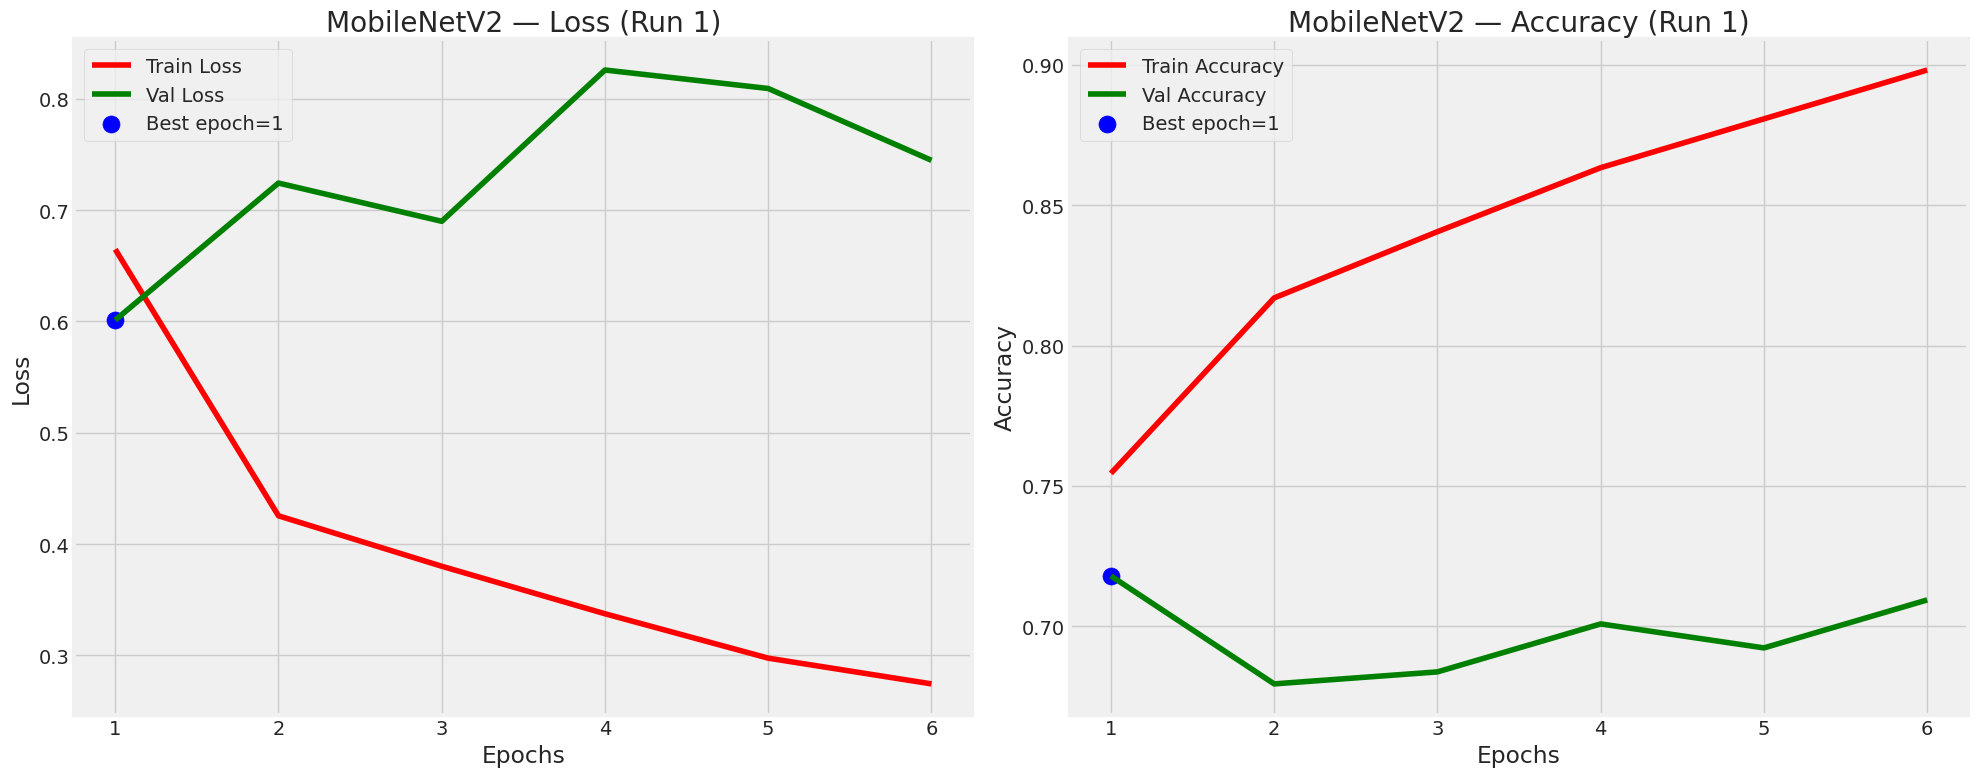

15/15 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step
              precision    recall  f1-score   support

      benign       0.69      0.79      0.74       117
   malignant       0.75      0.65      0.70       117

    accuracy                           0.72       234
   macro avg       0.72      0.72      0.72       234
weighted avg       0.72      0.72      0.72       234

15/15 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.7682 - loss: 0.4101


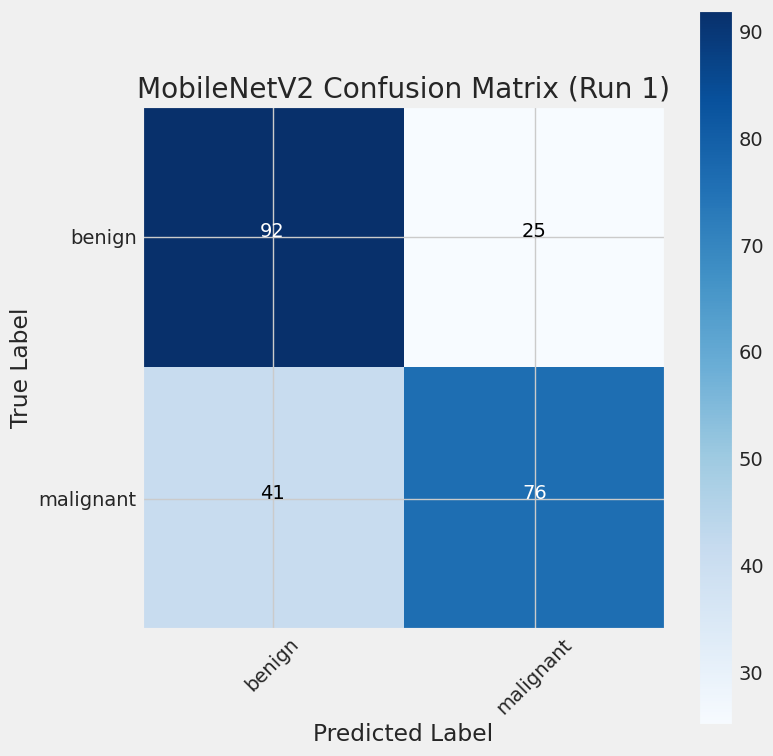

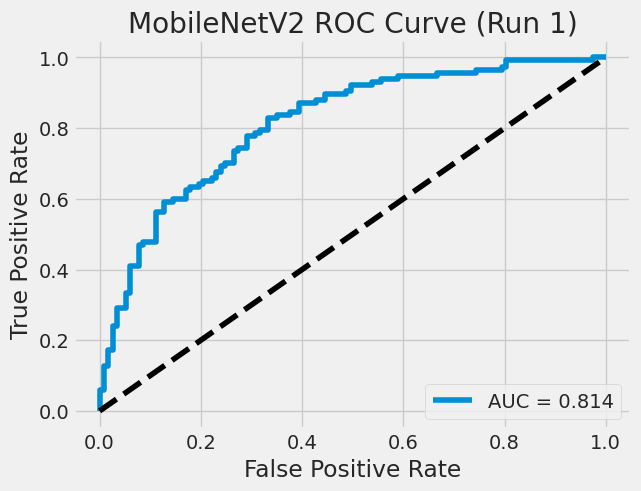


==================================================  MobileNetV2 Run 1
  test_loss                   : 0.4404
  test_accuracy               : 0.7708
  sensitivity                 : 0.6496
  PPV                         : 0.7525
  NPV                         : 0.6917
  AUC                         : 0.8141
  inference_time              : 0.0813
  f1_benign                   : 0.7360
  f1_malignant                : 0.6972
  precision_benign            : 0.6917
  recall_benign               : 0.7863
  precision_malignant         : 0.7525
  recall_malignant            : 0.6496
MobileNetV2 model size: 16.74 MB

--- ResNet50 (Run 1) ---
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,646,018 (94.02 MB)

 Trainable params: 1,054,210 (4.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 1081s 2s/step - accuracy: 0.7788 - loss: 0.8873 - val_accuracy: 0.6838 - val_loss: 0.8695
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 1074s 2s/step - accuracy: 0.8887 - loss: 0.2909 - val_accuracy: 0.7607 - val_loss: 0.6332
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 1081s 2s/step - accuracy: 0.9127 - loss: 0.2282 - val_accuracy: 0.6795 - val_loss: 1.1842
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 1062s 2s/step - accuracy: 0.9290 - loss: 0.1868 - val_accuracy: 0.6410 - val_loss: 1.8089
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 1054s 2s/step - accuracy: 0.9369 - loss: 0.1731 - val_accuracy: 0.6496 - val_loss: 1.3742
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 1102s 2s/step - accuracy: 0.9468 - loss: 0.1477 - val_accuracy: 0.6795 - val_loss: 1.3911
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 1132s 2s/step - accuracy: 0.9585 - loss: 0.1253 - val_accuracy: 0.6667 - val_loss: 1.8460

ResNet50 training time: 7588.1s


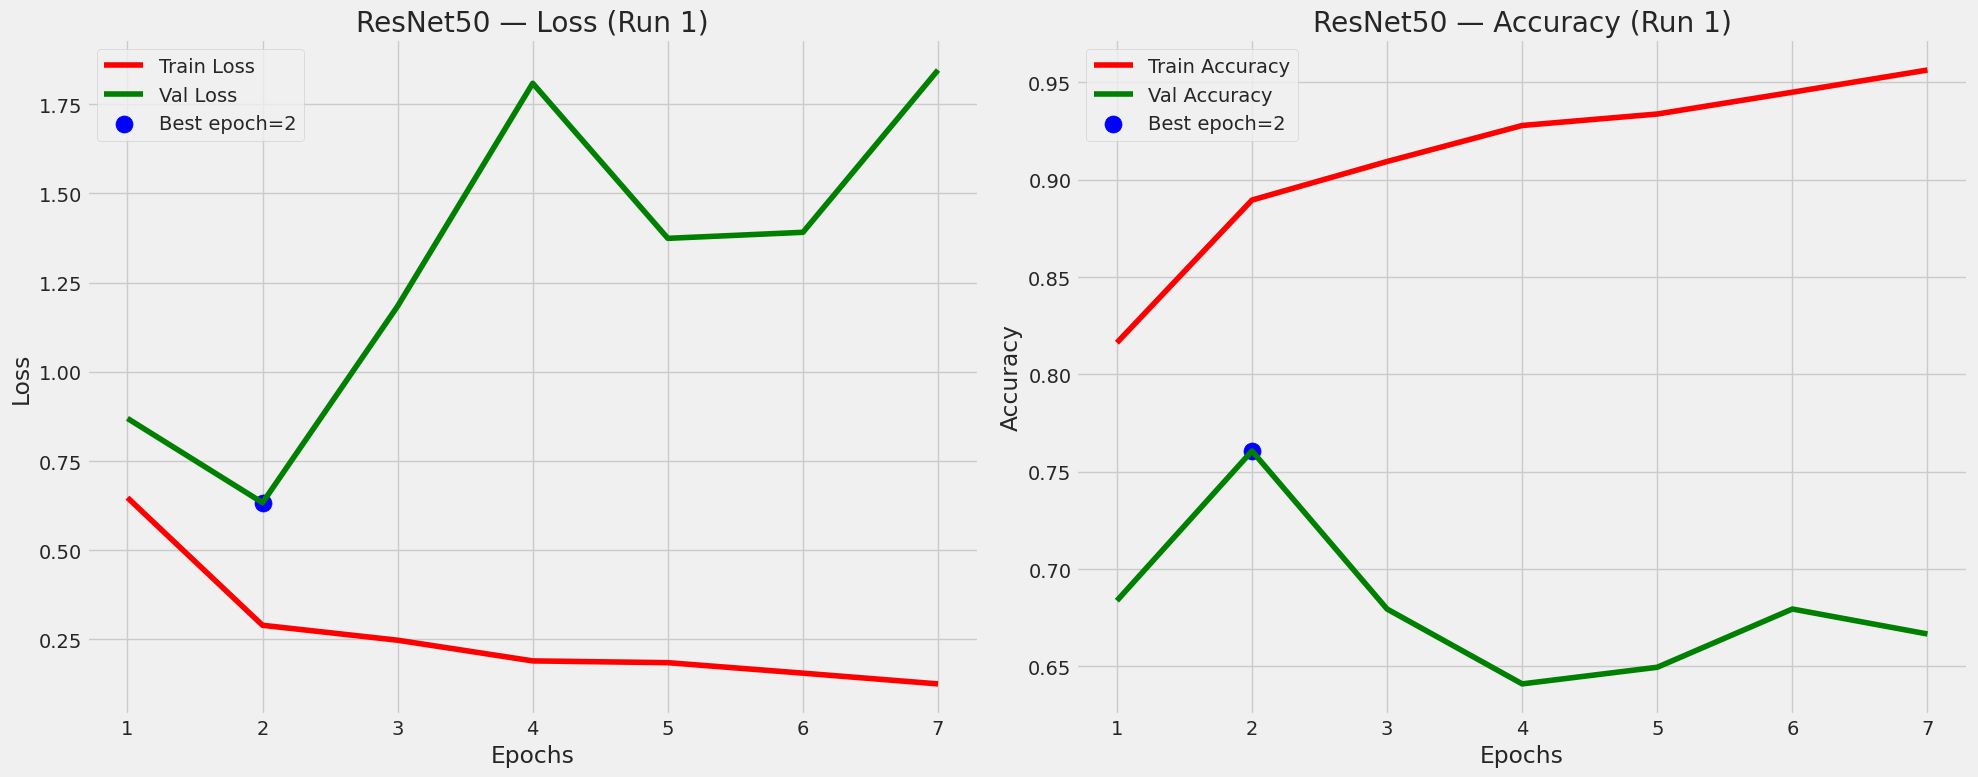

15/15 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step
              precision    recall  f1-score   support

      benign       0.71      0.87      0.78       117
   malignant       0.84      0.65      0.73       117

    accuracy                           0.76       234
   macro avg       0.77      0.76      0.76       234
weighted avg       0.77      0.76      0.76       234

15/15 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.8203 - loss: 0.4275


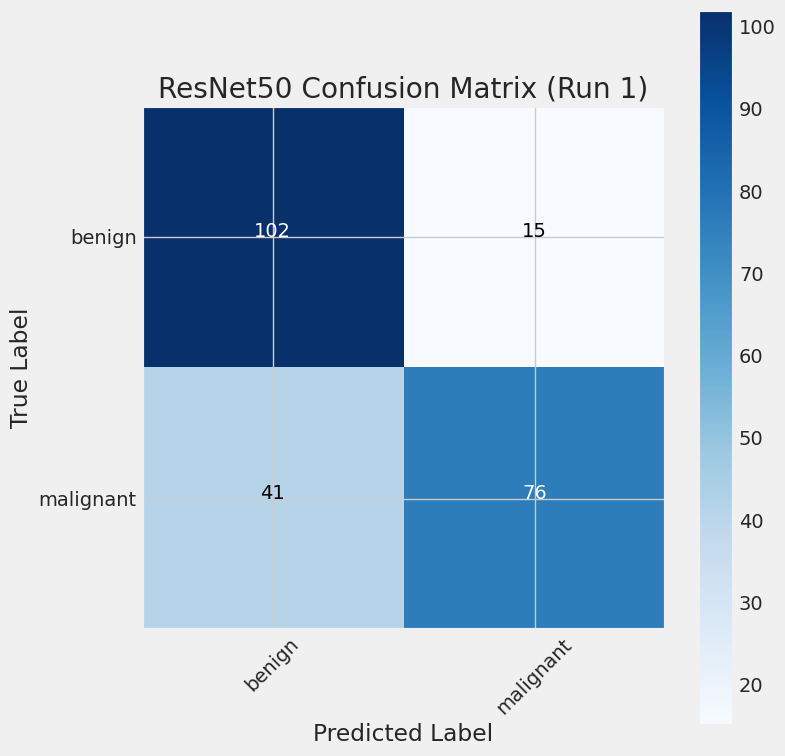

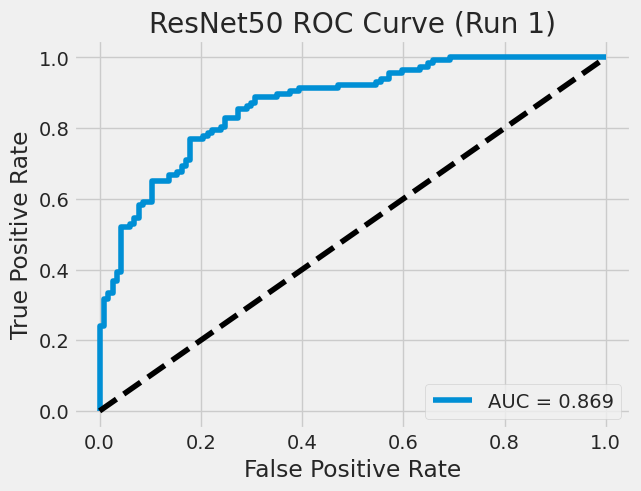


==================================================  ResNet50 Run 1
  test_loss                   : 0.4963
  test_accuracy               : 0.8125
  sensitivity                 : 0.6496
  PPV                         : 0.8352
  NPV                         : 0.7133
  AUC                         : 0.8689
  inference_time              : 0.1205
  f1_benign                   : 0.7846
  f1_malignant                : 0.7308
  precision_benign            : 0.7133
  recall_benign               : 0.8718
  precision_malignant         : 0.8352
  recall_malignant            : 0.6496
ResNet50 model size: 102.70 MB

############################################################
  RUN 2 / 3
############################################################

Found 10000 validated image filenames belonging to 2 classes.
Found 234 validated image filenames belonging to 2 classes.

--- MobileNetV2 (Run 2) ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,920,002 (11.14 MB)

 Trainable params: 659,458 (2.52 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 494s 780ms/step - accuracy: 0.7143 - loss: 0.8964 - val_accuracy: 0.7350 - val_loss: 0.5586
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 504s 806ms/step - accuracy: 0.8121 - loss: 0.4279 - val_accuracy: 0.6966 - val_loss: 0.6898
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 543s 776ms/step - accuracy: 0.8415 - loss: 0.3673 - val_accuracy: 0.7479 - val_loss: 0.5794
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 483s 772ms/step - accuracy: 0.8695 - loss: 0.3247 - val_accuracy: 0.6325 - val_loss: 0.8869
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 499s 767ms/step - accuracy: 0.8795 - loss: 0.2981 - val_accuracy: 0.7137 - val_loss: 0.6873
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 477s 763ms/step - accuracy: 0.8951 - loss: 0.2691 - val_accuracy: 0.7222 - val_loss: 0.7181

MobileNetV2 training time: 3001.2s


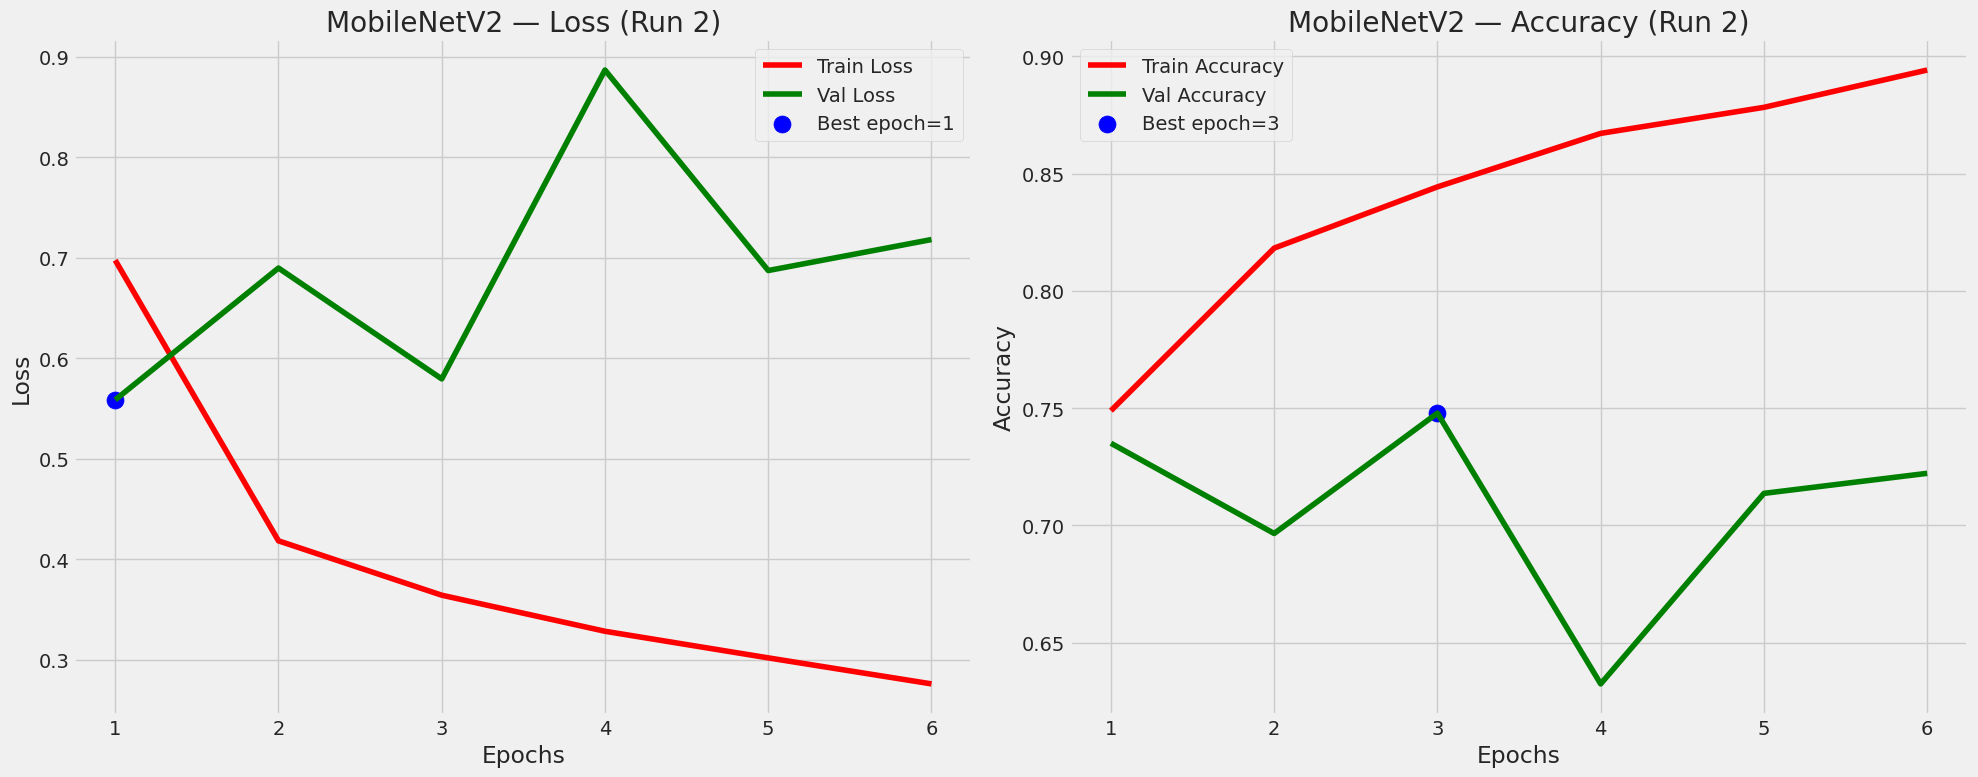

15/15 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step
              precision    recall  f1-score   support

      benign       0.69      0.85      0.76       117
   malignant       0.81      0.62      0.70       117

    accuracy                           0.74       234
   macro avg       0.75      0.74      0.73       234
weighted avg       0.75      0.74      0.73       234

15/15 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.8359 - loss: 0.4022


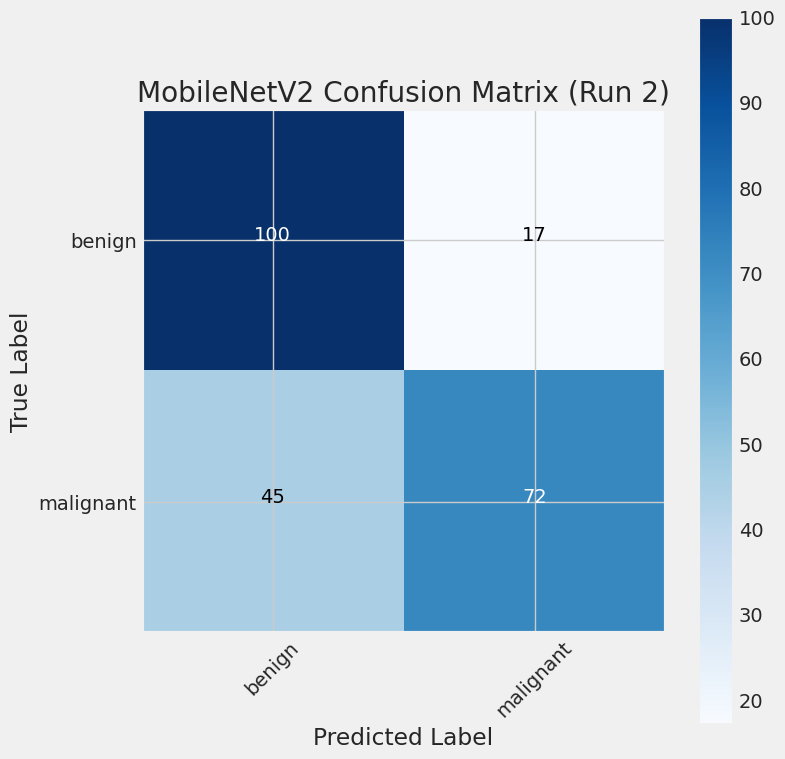

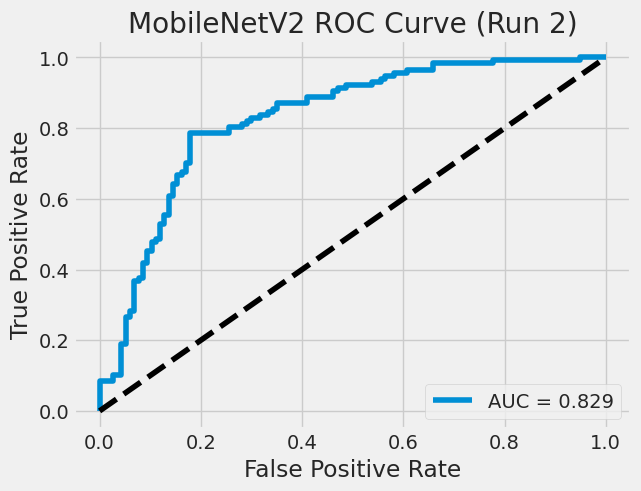


==================================================  MobileNetV2 Run 2
  test_loss                   : 0.4029
  test_accuracy               : 0.8125
  sensitivity                 : 0.6154
  PPV                         : 0.8090
  NPV                         : 0.6897
  AUC                         : 0.8288
  inference_time              : 0.0767
  f1_benign                   : 0.7634
  f1_malignant                : 0.6990
  precision_benign            : 0.6897
  recall_benign               : 0.8547
  precision_malignant         : 0.8090
  recall_malignant            : 0.6154
MobileNetV2 model size: 16.74 MB

--- ResNet50 (Run 2) ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,646,018 (94.02 MB)

 Trainable params: 1,054,210 (4.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 1053s 2s/step - accuracy: 0.7865 - loss: 0.8414 - val_accuracy: 0.7137 - val_loss: 0.8280
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 1034s 2s/step - accuracy: 0.8928 - loss: 0.2796 - val_accuracy: 0.7051 - val_loss: 0.7160
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 1049s 2s/step - accuracy: 0.9190 - loss: 0.2225 - val_accuracy: 0.6923 - val_loss: 1.2273
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 1054s 2s/step - accuracy: 0.9268 - loss: 0.2040 - val_accuracy: 0.7350 - val_loss: 1.1687
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 1050s 2s/step - accuracy: 0.9462 - loss: 0.1555 - val_accuracy: 0.6709 - val_loss: 1.3869
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 1058s 2s/step - accuracy: 0.9497 - loss: 0.1532 - val_accuracy: 0.6667 - val_loss: 1.8288
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 1108s 2s/step - accuracy: 0.9530 - loss: 0.1291 - val_accuracy: 0.6752 - val_loss: 1.5604

ResNet50 training time: 7408.4s


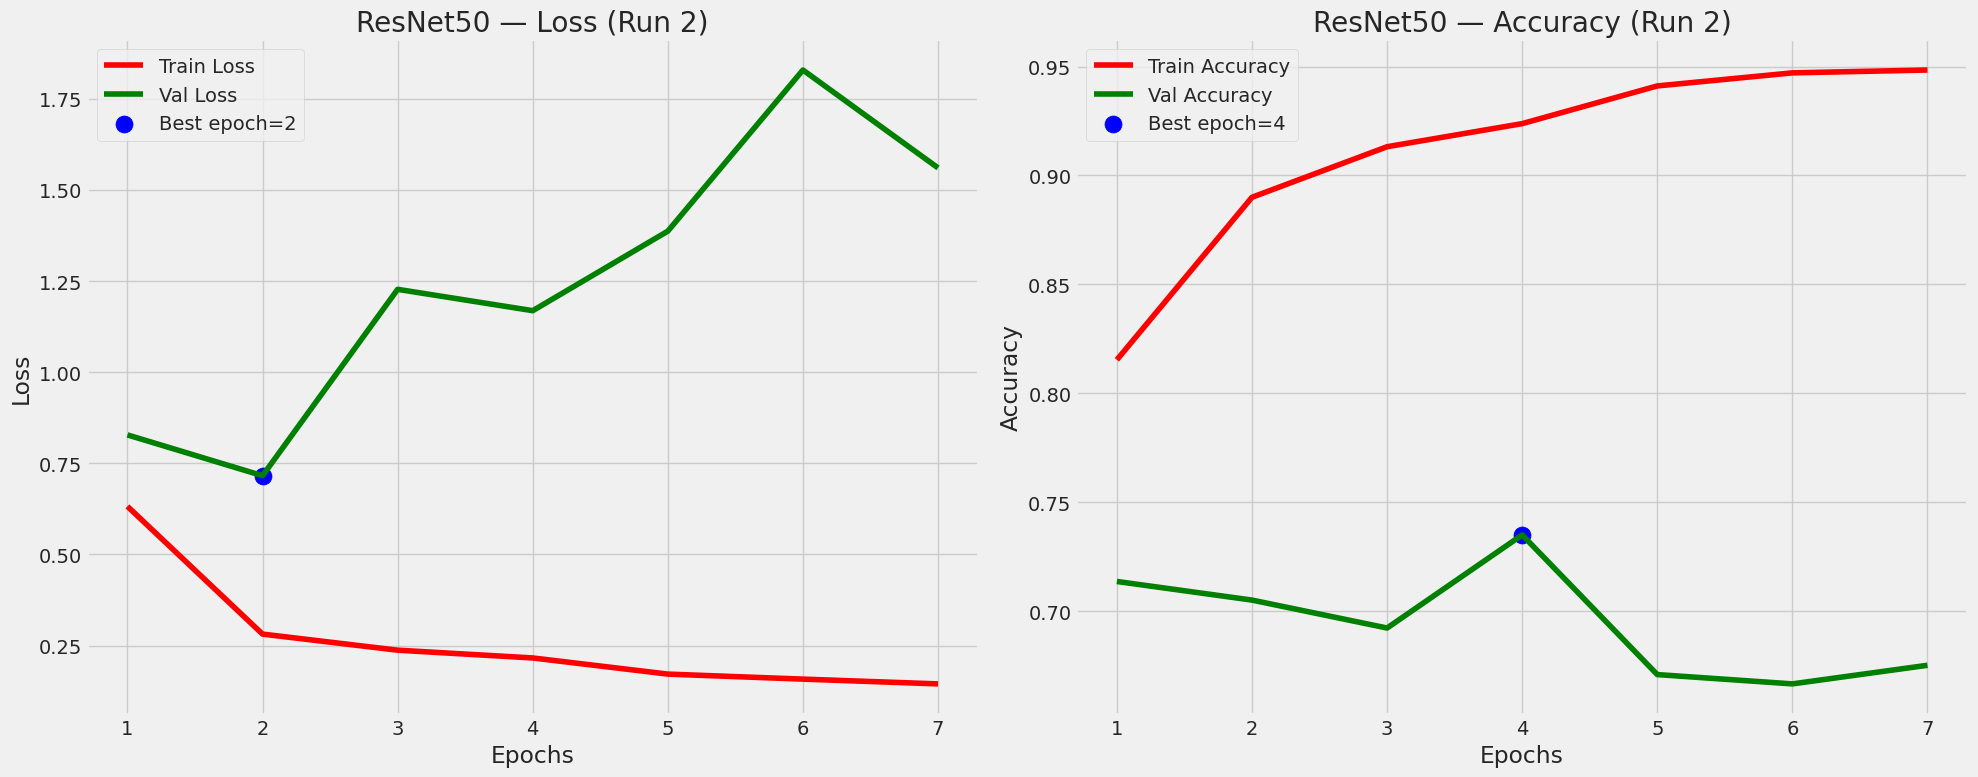

15/15 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step
              precision    recall  f1-score   support

      benign       0.64      0.91      0.76       117
   malignant       0.85      0.50      0.63       117

    accuracy                           0.71       234
   macro avg       0.75      0.71      0.69       234
weighted avg       0.75      0.71      0.69       234

15/15 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.7396 - loss: 0.4513


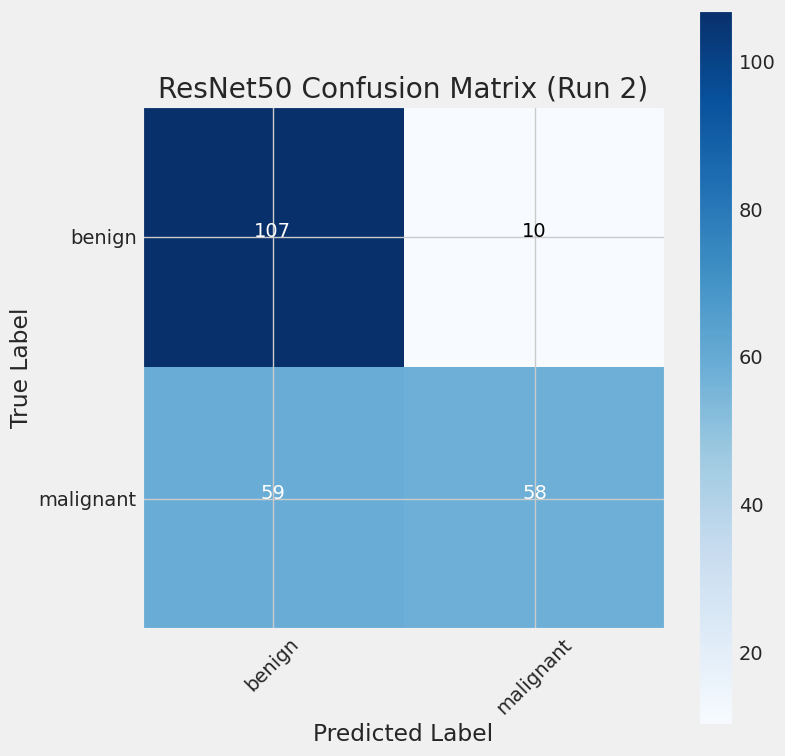

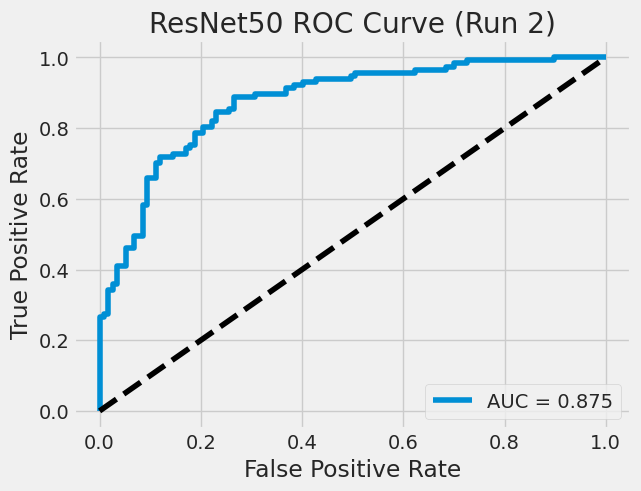


==================================================  ResNet50 Run 2
  test_loss                   : 0.5428
  test_accuracy               : 0.7292
  sensitivity                 : 0.4957
  PPV                         : 0.8529
  NPV                         : 0.6446
  AUC                         : 0.8748
  inference_time              : 0.1224
  f1_benign                   : 0.7562
  f1_malignant                : 0.6270
  precision_benign            : 0.6446
  recall_benign               : 0.9145
  precision_malignant         : 0.8529
  recall_malignant            : 0.4957
ResNet50 model size: 102.70 MB

############################################################
  RUN 3 / 3
############################################################

Found 10000 validated image filenames belonging to 2 classes.
Found 234 validated image filenames belonging to 2 classes.

--- MobileNetV2 (Run 3) ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,920,002 (11.14 MB)

 Trainable params: 659,458 (2.52 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 490s 775ms/step - accuracy: 0.7114 - loss: 0.8299 - val_accuracy: 0.7564 - val_loss: 0.5136
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 534s 853ms/step - accuracy: 0.8207 - loss: 0.4053 - val_accuracy: 0.6966 - val_loss: 0.6192
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 485s 776ms/step - accuracy: 0.8474 - loss: 0.3576 - val_accuracy: 0.7393 - val_loss: 0.6494
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 479s 765ms/step - accuracy: 0.8572 - loss: 0.3398 - val_accuracy: 0.7393 - val_loss: 0.6071
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 497s 795ms/step - accuracy: 0.8796 - loss: 0.2871 - val_accuracy: 0.7692 - val_loss: 0.6214
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 492s 786ms/step - accuracy: 0.8988 - loss: 0.2585 - val_accuracy: 0.6838 - val_loss: 0.8010

MobileNetV2 training time: 2978.0s


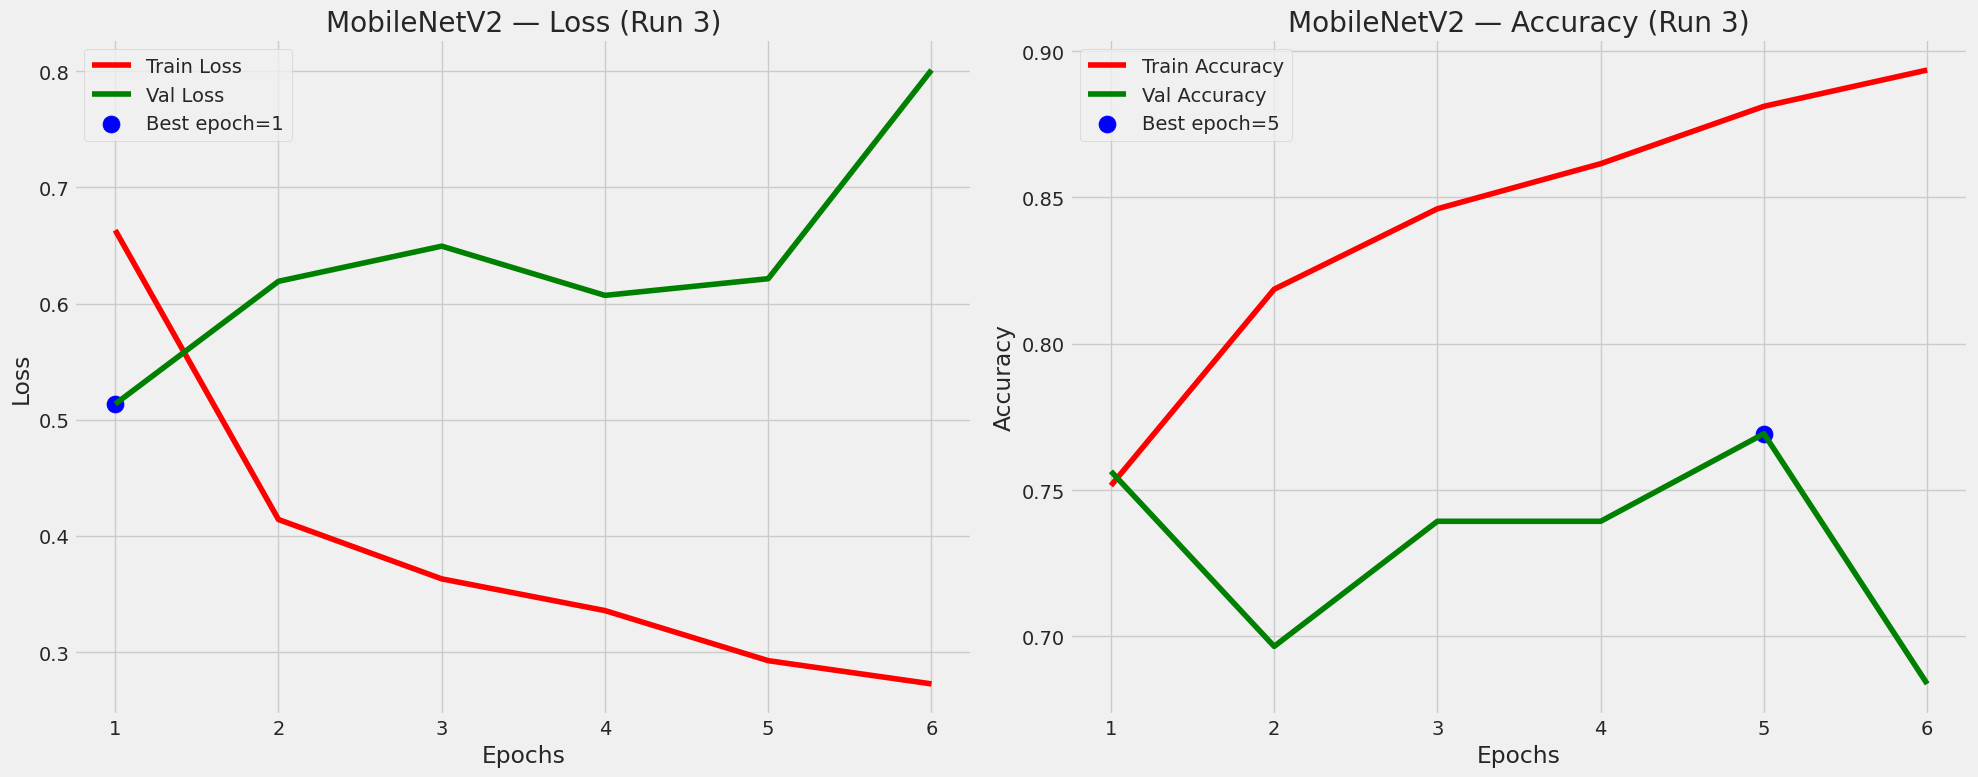

15/15 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step
              precision    recall  f1-score   support

      benign       0.72      0.83      0.77       117
   malignant       0.80      0.68      0.74       117

    accuracy                           0.76       234
   macro avg       0.76      0.76      0.76       234
weighted avg       0.76      0.76      0.76       234

15/15 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.8125 - loss: 0.3723


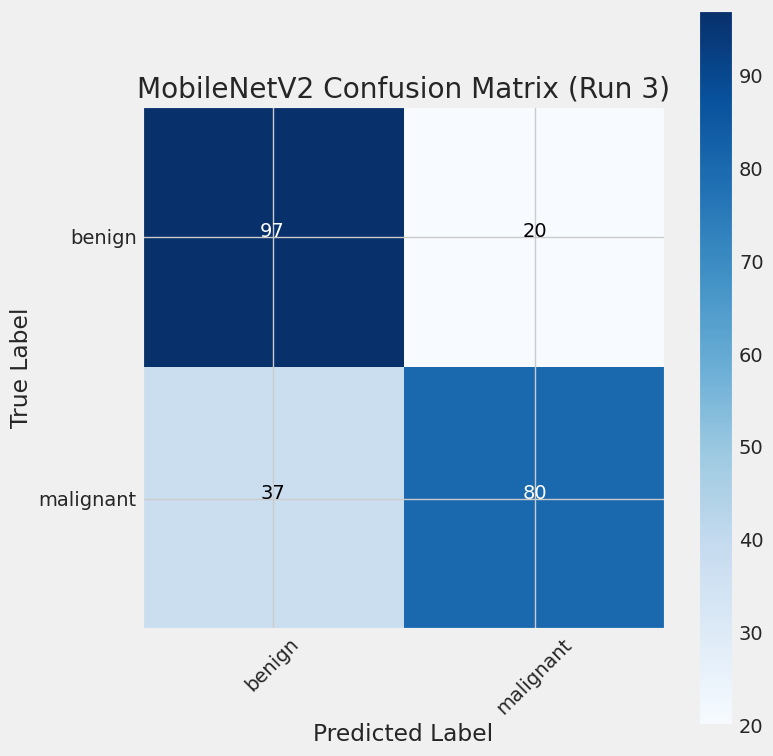

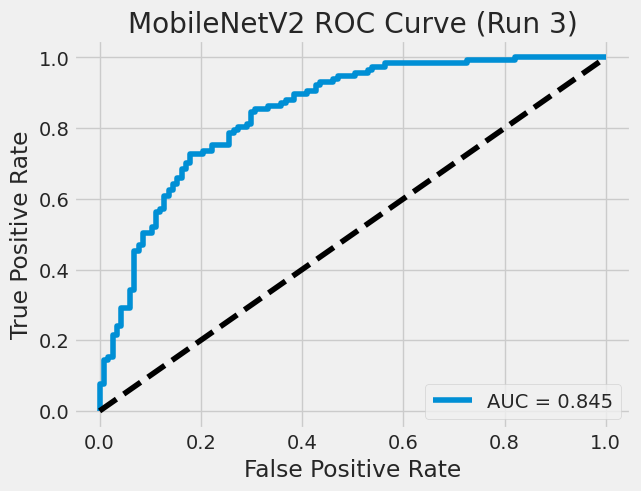


==================================================  MobileNetV2 Run 3
  test_loss                   : 0.3892
  test_accuracy               : 0.8125
  sensitivity                 : 0.6838
  PPV                         : 0.8000
  NPV                         : 0.7239
  AUC                         : 0.8448
  inference_time              : 0.0829
  f1_benign                   : 0.7729
  f1_malignant                : 0.7373
  precision_benign            : 0.7239
  recall_benign               : 0.8291
  precision_malignant         : 0.8000
  recall_malignant            : 0.6838
MobileNetV2 model size: 16.74 MB

--- ResNet50 (Run 3) ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,646,018 (94.02 MB)

 Trainable params: 1,054,210 (4.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 1081s 2s/step - accuracy: 0.7641 - loss: 0.8910 - val_accuracy: 0.6795 - val_loss: 0.9759
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 1045s 2s/step - accuracy: 0.8938 - loss: 0.2766 - val_accuracy: 0.7393 - val_loss: 0.7945
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 1064s 2s/step - accuracy: 0.9137 - loss: 0.2309 - val_accuracy: 0.7650 - val_loss: 0.6528
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 1051s 2s/step - accuracy: 0.9336 - loss: 0.1898 - val_accuracy: 0.6496 - val_loss: 1.3593
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 1038s 2s/step - accuracy: 0.9415 - loss: 0.1637 - val_accuracy: 0.6923 - val_loss: 1.3986
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 1044s 2s/step - accuracy: 0.9490 - loss: 0.1509 - val_accuracy: 0.6667 - val_loss: 1.8228
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 1043s 2s/step - accuracy: 0.9573 - loss: 0.1327 - val_accuracy: 0.7051 - val_loss: 1.4464
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 1040s 2s/step - accuracy: 0.9447 - loss: 0.1721 - 

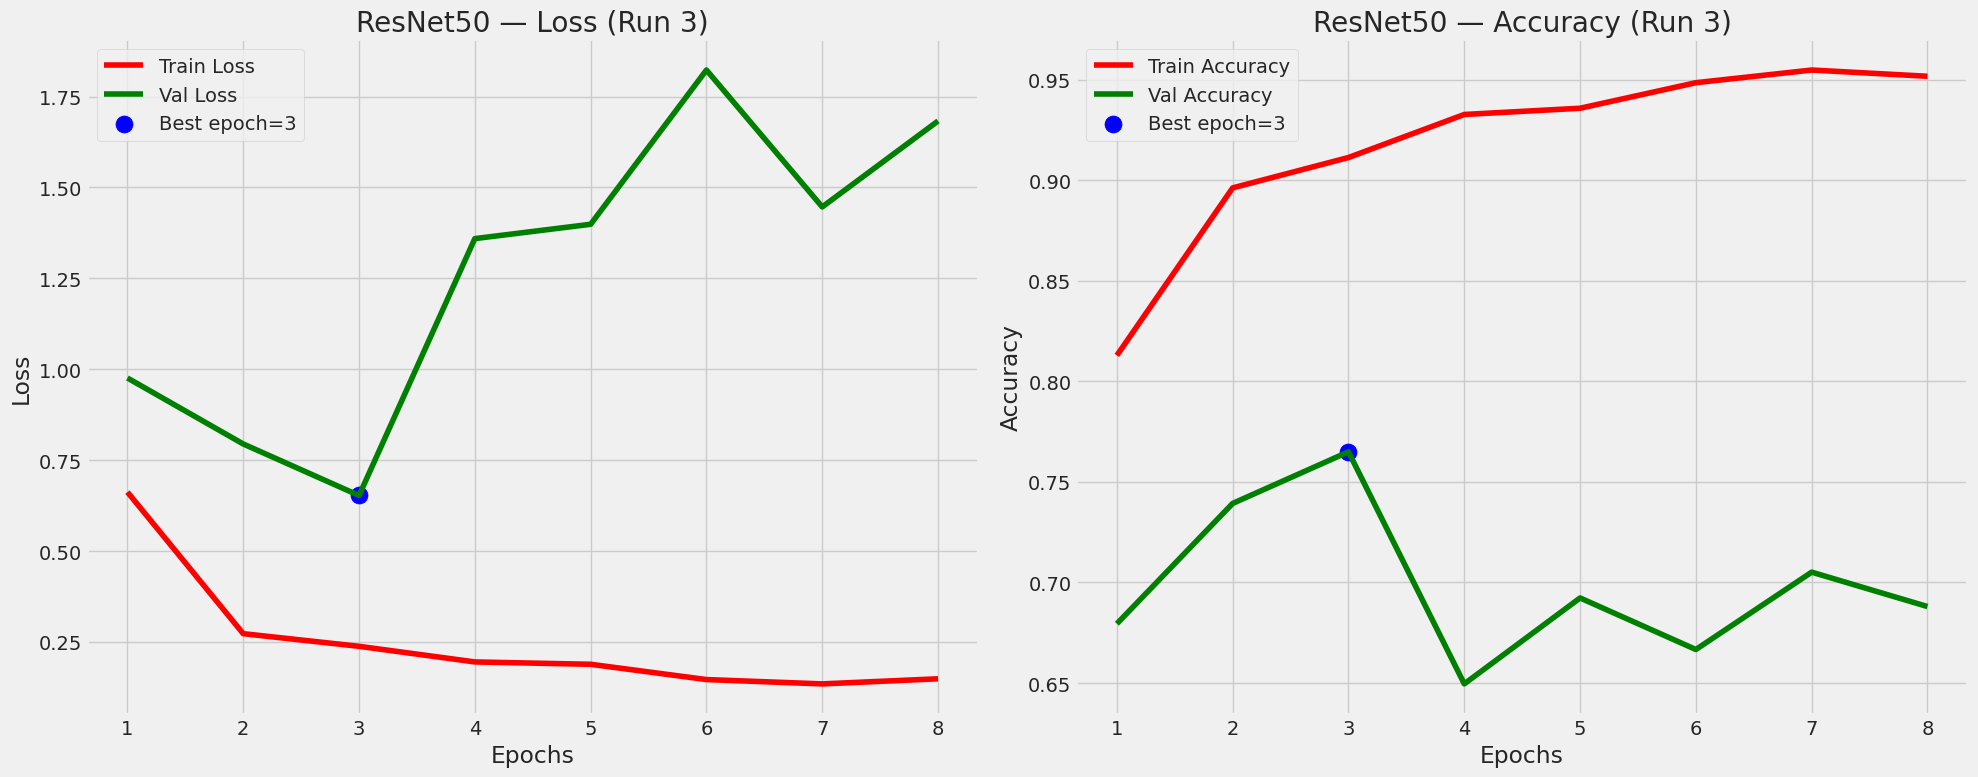

15/15 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step
              precision    recall  f1-score   support

      benign       0.71      0.89      0.79       117
   malignant       0.85      0.64      0.73       117

    accuracy                           0.76       234
   macro avg       0.78      0.76      0.76       234
weighted avg       0.78      0.76      0.76       234

15/15 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.7422 - loss: 0.4987


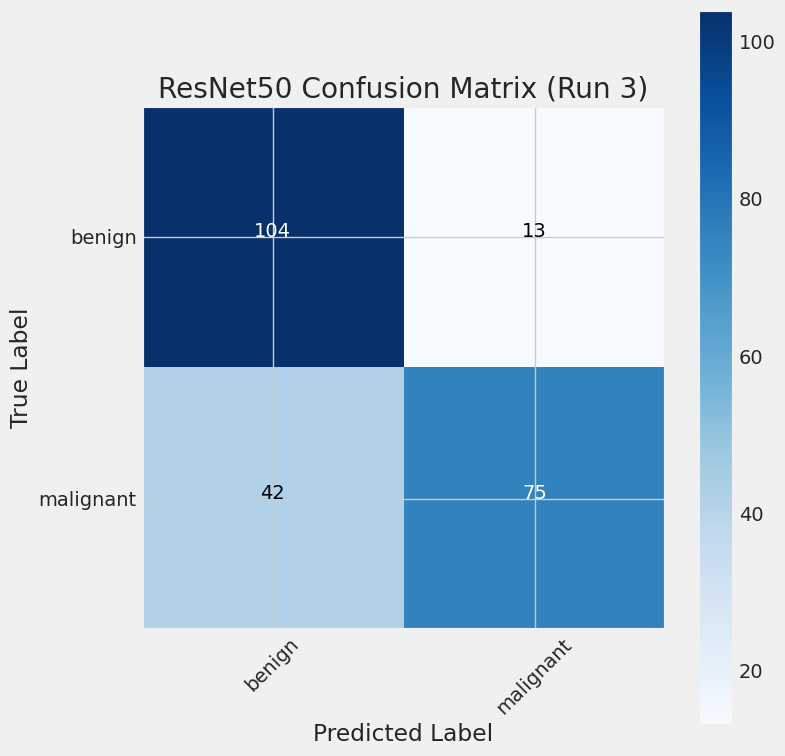

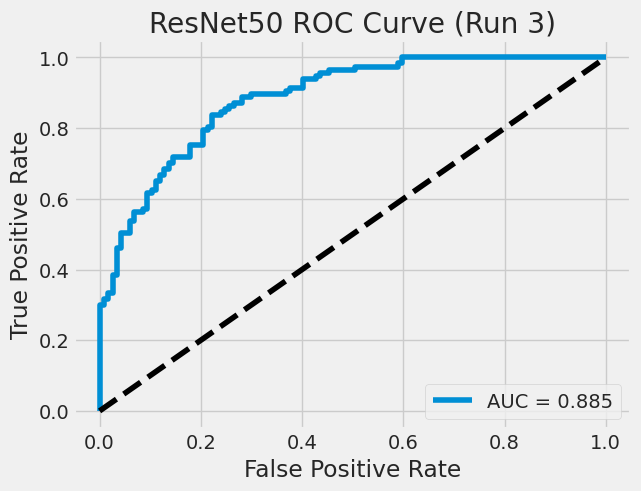


==================================================  ResNet50 Run 3
  test_loss                   : 0.4797
  test_accuracy               : 0.7500
  sensitivity                 : 0.6410
  PPV                         : 0.8523
  NPV                         : 0.7123
  AUC                         : 0.8847
  inference_time              : 0.1227
  f1_benign                   : 0.7909
  f1_malignant                : 0.7317
  precision_benign            : 0.7123
  recall_benign               : 0.8889
  precision_malignant         : 0.8523
  recall_malignant            : 0.6410
ResNet50 model size: 102.70 MB


In [11]:
all_results = {'MobileNetV2': [], 'ResNet50': []}

for run in range(1, N_RUNS + 1):
    print(f"\n{'#'*60}")
    print(f"  RUN {run} / {N_RUNS}")
    print(f"{'#'*60}\n")

    tf.keras.backend.clear_session()
    gc.collect()

    train_gen, test_gen = build_generators(train_df_balanced, test_df)
    classes     = list(train_gen.class_indices.keys())
    class_count = len(classes)
    early_stop  = EarlyStopping(monitor='val_loss', patience=5,
                                restore_best_weights=True)

    # ── MobileNetV2 ───────────────────────────────────────────────────────
    print(f"\n--- MobileNetV2 (Run {run}) ---")
    model_mv2 = build_mobilenetv2(IMG_SHAPE, class_count)
    model_mv2.summary()

    t0 = time.time()
    hist_mv2 = model_mv2.fit(train_gen, epochs=EPOCHS, verbose=1,
                              validation_data=test_gen,
                              callbacks=[early_stop], shuffle=False)
    print(f"\nMobileNetV2 training time: {time.time()-t0:.1f}s")

    plot_history(hist_mv2, 'MobileNetV2', run)
    m1 = evaluate_model(model_mv2, test_gen, classes, 'MobileNetV2', run)

    mv2_path = f'/kaggle/working/mobilenetv2_run{run}.keras'
    model_mv2.save(mv2_path)
    m1['model_size_MB'] = os.path.getsize(mv2_path) / (1024 * 1024)
    print(f"MobileNetV2 model size: {m1['model_size_MB']:.2f} MB")
    all_results['MobileNetV2'].append(m1)

    del model_mv2; gc.collect(); tf.keras.backend.clear_session()

    # ── ResNet50 ──────────────────────────────────────────────────────────
    print(f"\n--- ResNet50 (Run {run}) ---")
    model_rn50 = build_resnet50(IMG_SHAPE, class_count)
    model_rn50.summary()

    t0 = time.time()
    hist_rn50 = model_rn50.fit(train_gen, epochs=EPOCHS, verbose=1,
                                validation_data=test_gen,
                                callbacks=[early_stop], shuffle=False)
    print(f"\nResNet50 training time: {time.time()-t0:.1f}s")

    plot_history(hist_rn50, 'ResNet50', run)
    m2 = evaluate_model(model_rn50, test_gen, classes, 'ResNet50', run)

    rn50_path = f'/kaggle/working/resnet50_run{run}.keras'
    model_rn50.save(rn50_path)
    m2['model_size_MB'] = os.path.getsize(rn50_path) / (1024 * 1024)
    print(f"ResNet50 model size: {m2['model_size_MB']:.2f} MB")
    all_results['ResNet50'].append(m2)

    del model_rn50; gc.collect()

## 11. Mean Results Across All Runs

In [12]:
metric_keys = [
    'test_loss', 'test_accuracy', 'sensitivity', 'PPV', 'NPV',
    'AUC', 'inference_time', 'f1_benign', 'f1_malignant',
    'precision_benign', 'recall_benign', 'precision_malignant',
    'recall_malignant', 'model_size_MB'
]

summary_rows = []
for model_name, runs in all_results.items():
    row = {'Model': model_name}
    for k in metric_keys:
        vals = [r[k] for r in runs if k in r]
        row[f'{k}_mean'] = np.mean(vals)
        row[f'{k}_std']  = np.std(vals)
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv('/kaggle/working/mean_results_summary.csv', index=False)

print(f"{'='*60}")
print("  MEAN RESULTS ACROSS ALL RUNS — ISIC 2020")
print(f"{'='*60}")
for row in summary_rows:
    print(f"\n{row['Model']}:")
    for k in metric_keys:
        print(f"  {k:<30}: {row[f'{k}_mean']:.4f} ± {row[f'{k}_std']:.4f}")
print("\nSaved → /kaggle/working/mean_results_summary.csv")

  MEAN RESULTS ACROSS ALL RUNS — ISIC 2020

MobileNetV2:
  test_loss                     : 0.4108 ± 0.0216
  test_accuracy                 : 0.7986 ± 0.0196
  sensitivity                   : 0.6496 ± 0.0279
  PPV                           : 0.7872 ± 0.0248
  NPV                           : 0.7018 ± 0.0157
  AUC                           : 0.8293 ± 0.0126
  inference_time                : 0.0803 ± 0.0026
  f1_benign                     : 0.7574 ± 0.0156
  f1_malignant                  : 0.7112 ± 0.0185
  precision_benign              : 0.7018 ± 0.0157
  recall_benign                 : 0.8234 ± 0.0282
  precision_malignant           : 0.7872 ± 0.0248
  recall_malignant              : 0.6496 ± 0.0279
  model_size_MB                 : 16.7390 ± 0.0000

ResNet50:
  test_loss                     : 0.5063 ± 0.0267
  test_accuracy                 : 0.7639 ± 0.0354
  sensitivity                   : 0.5954 ± 0.0706
  PPV                           : 0.8468 ± 0.0082
  NPV                          

## 12. Final Comparison Table

In [13]:
display_metrics = [
    'test_accuracy', 'sensitivity', 'PPV', 'NPV',
    'AUC', 'f1_malignant', 'inference_time', 'model_size_MB'
]

model_names = list(all_results.keys())
table_data  = {}
for k in display_metrics:
    table_data[k] = []
    for mn in model_names:
        row = next(r for r in summary_rows if r['Model'] == mn)
        table_data[k].append(f"{row[f'{k}_mean']:.4f} ± {row[f'{k}_std']:.4f}")

comparison_df = pd.DataFrame(table_data, index=model_names).T
comparison_df.index.name = 'Metric'
print(comparison_df.to_string())
comparison_df

                     MobileNetV2           ResNet50
Metric                                             
test_accuracy    0.7986 ± 0.0196    0.7639 ± 0.0354
sensitivity      0.6496 ± 0.0279    0.5954 ± 0.0706
PPV              0.7872 ± 0.0248    0.8468 ± 0.0082
NPV              0.7018 ± 0.0157    0.6901 ± 0.0322
AUC              0.8293 ± 0.0126    0.8761 ± 0.0065
f1_malignant     0.7112 ± 0.0185    0.6965 ± 0.0491
inference_time   0.0803 ± 0.0026    0.1218 ± 0.0010
model_size_MB   16.7390 ± 0.0000  102.6959 ± 0.0000


,MobileNetV2,ResNet50
Metric,,
test_accuracy,0.7986 ± 0.0196,0.7639 ± 0.0354
sensitivity,0.6496 ± 0.0279,0.5954 ± 0.0706
PPV,0.7872 ± 0.0248,0.8468 ± 0.0082
NPV,0.7018 ± 0.0157,0.6901 ± 0.0322
AUC,0.8293 ± 0.0126,0.8761 ± 0.0065
f1_malignant,0.7112 ± 0.0185,0.6965 ± 0.0491
inference_time,0.0803 ± 0.0026,0.1218 ± 0.0010
model_size_MB,16.7390 ± 0.0000,102.6959 ± 0.0000
